# Feature Analysis

In [1]:
team = "Aston Martin"
grand_prix = "Japanese Grand Prix"
year = 2025

In [2]:
import sys
import fastf1
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.load_save_data import *
from src.preprocess_data import *
from src.explore_data import *
from src.feature_engineering import *

In [3]:
session = fastf1.get_session(year, grand_prix, "Q")
session.load()

driver_1, driver_2 = get_drivers(session, team)
segment = get_segment(session, driver_1, driver_2)
turns = get_turns(session)

try:
    lap_1, lap_2 = load_cache(year, grand_prix, segment, driver_1, driver_2)
except Exception as e:
    print(f"Processed data for {year} {grand_prix} {driver_1} and {driver_2} not found: {e}")

req         WARNING 	DEFAULT CACHE ENABLED! (598.78 MB) C:\Users\joseg\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.7.0]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '16', '63', '12', '6', '44', '23', '87', '10', '55', '14', '30', '22', '27', '5', '31', '7', '18']



Processed data for 2025 Japanese Grand Prix ALO and STR found in cache.
Driver 1: ALO, Driver 2: STR, Segment: Q1


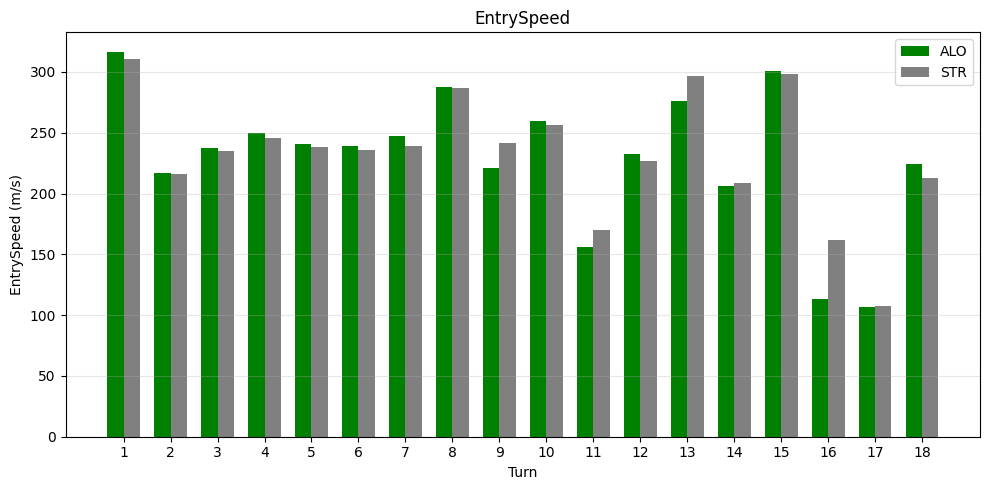

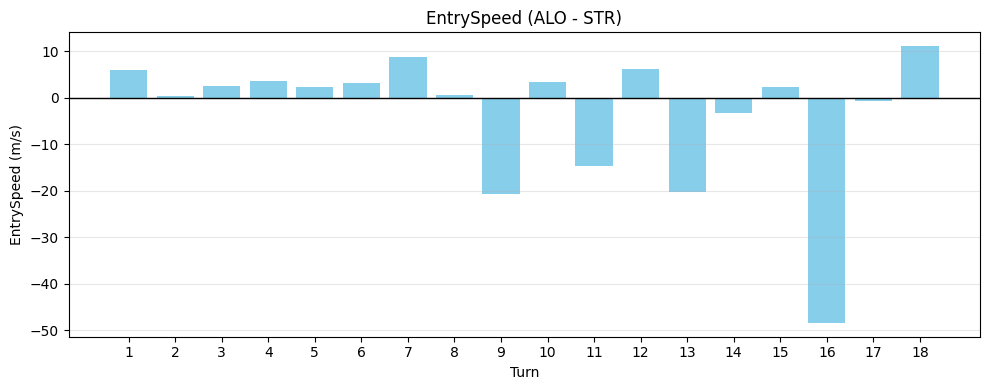

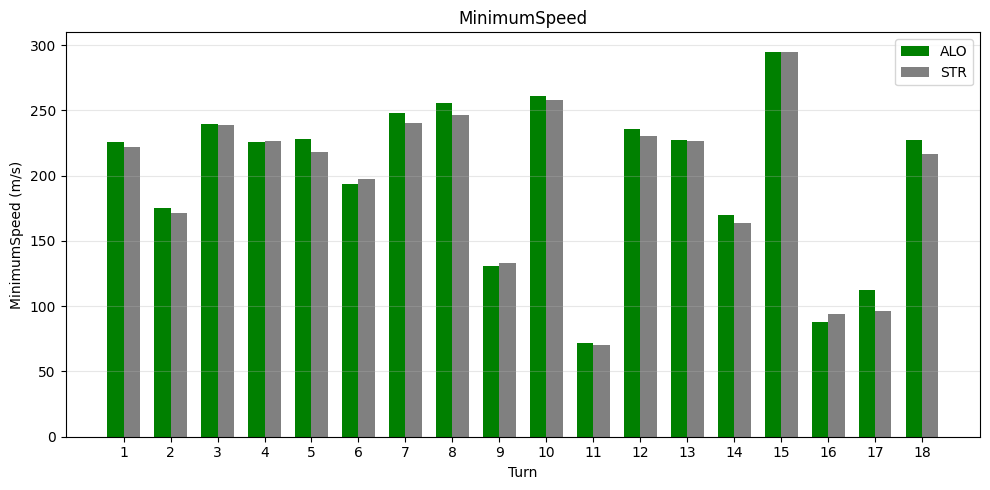

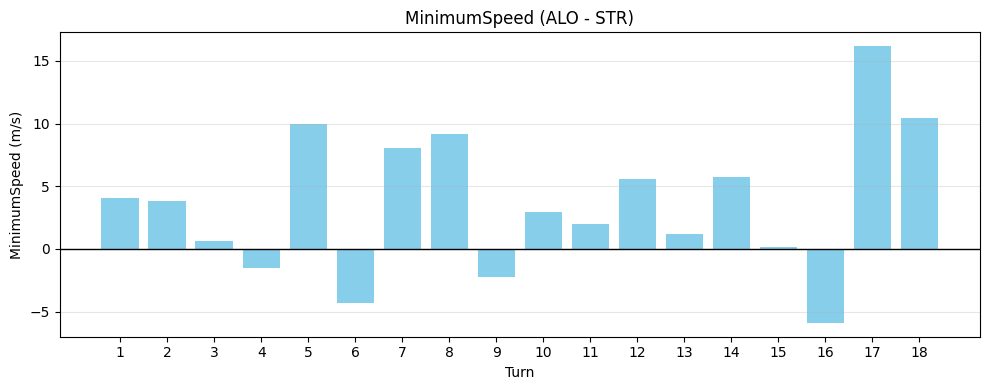

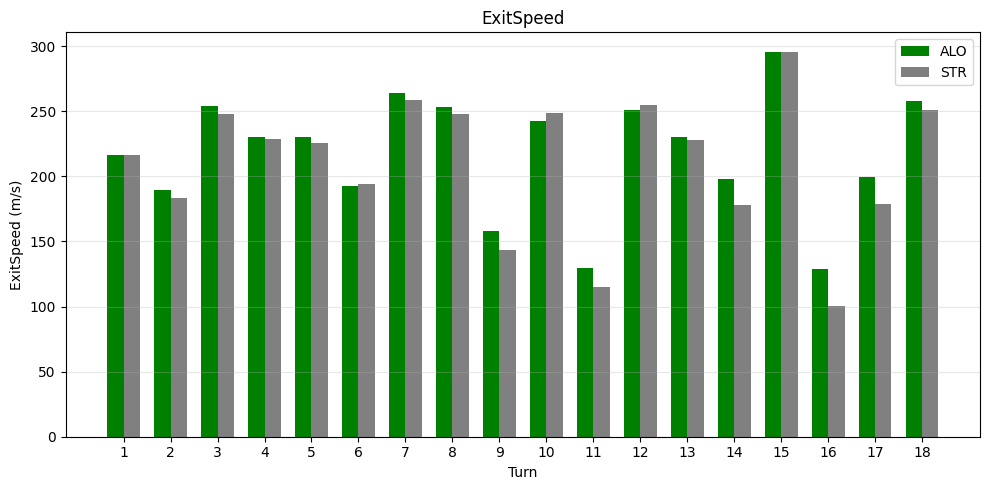

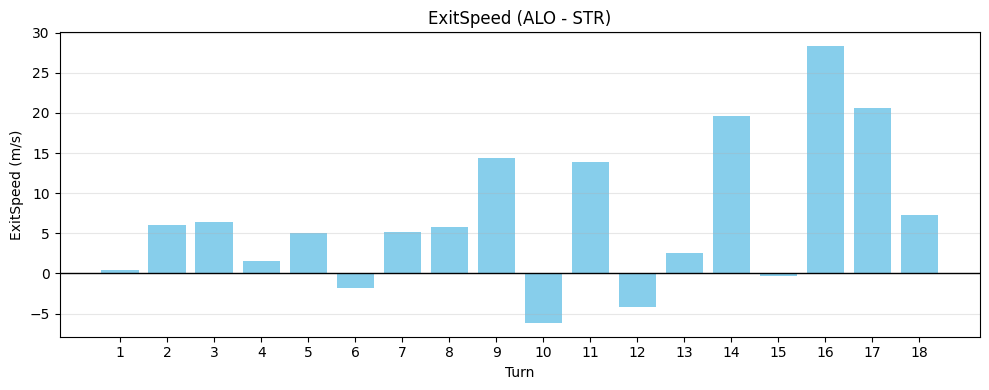

In [4]:
for feature in ["EntrySpeed", "MinimumSpeed", "ExitSpeed"]:
    barplot_feature_comparison(lap_1["Corners"], lap_2["Corners"], driver_1, driver_2, turns, feature, "m/s")
    barplot_feature_delta(lap_1["Corners"], lap_2["Corners"], driver_1, driver_2, turns, feature, "m/s")

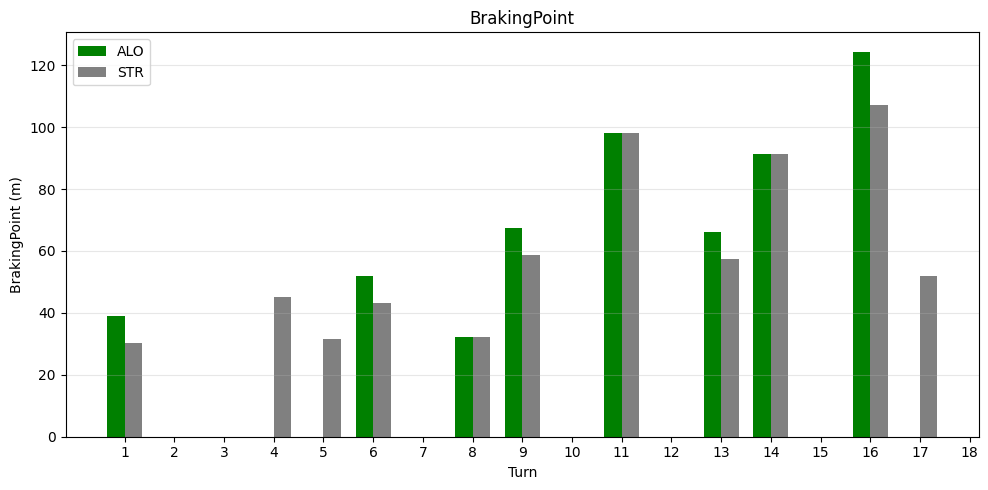

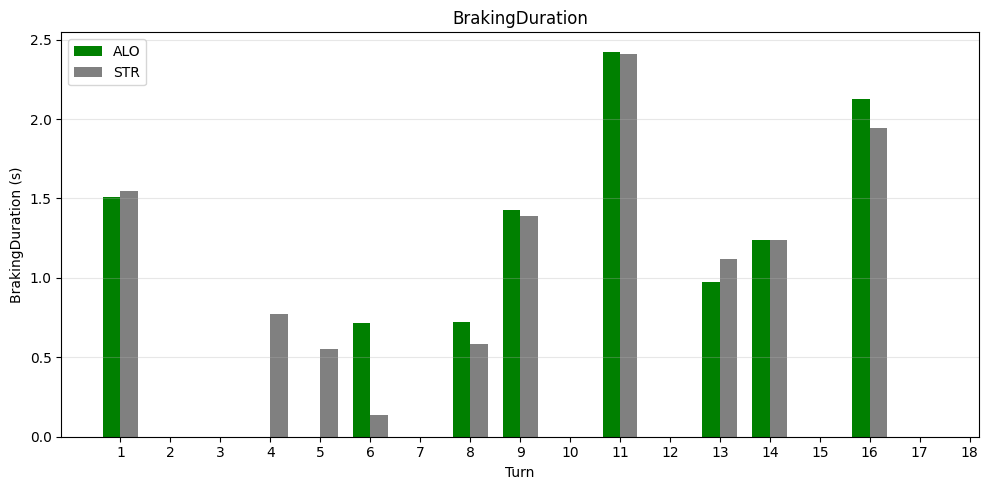

In [5]:
barplot_feature_comparison(lap_1["BrakingZones"], lap_2["BrakingZones"], driver_1, driver_2, turns, "BrakingPoint", y_unit="m")
barplot_feature_comparison(lap_1["BrakingZones"], lap_2["BrakingZones"], driver_1, driver_2, turns, "BrakingDuration", y_unit="s")

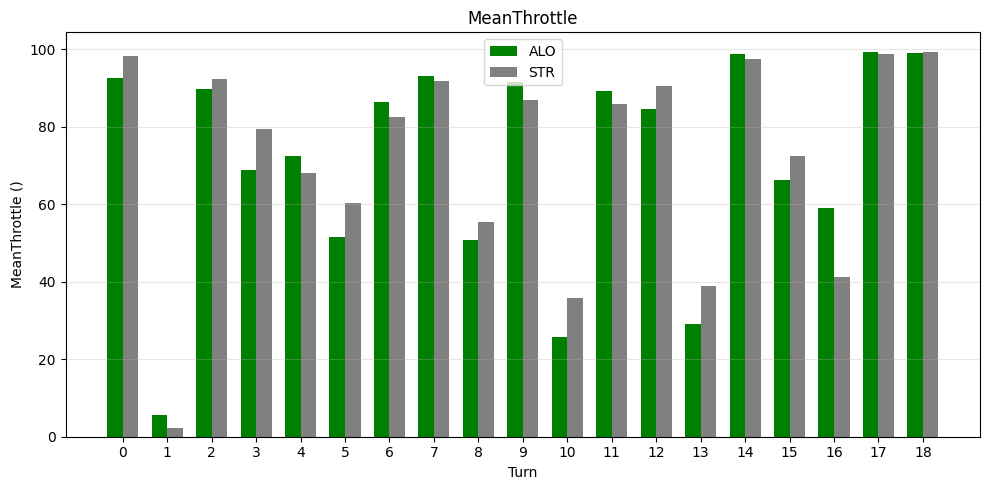

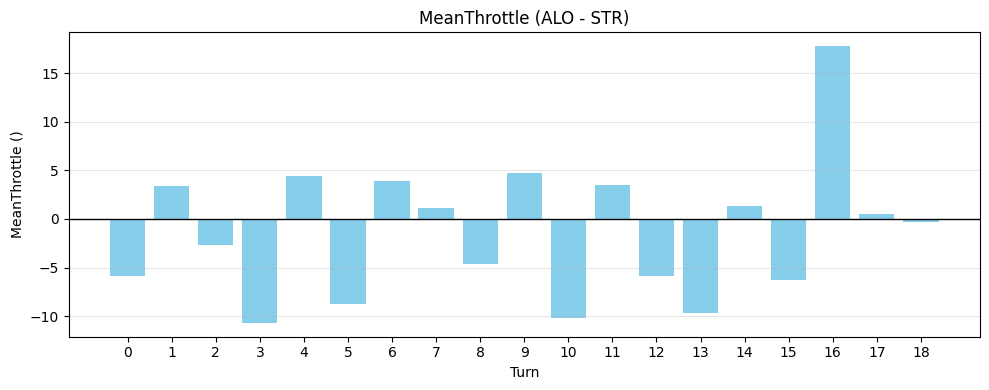

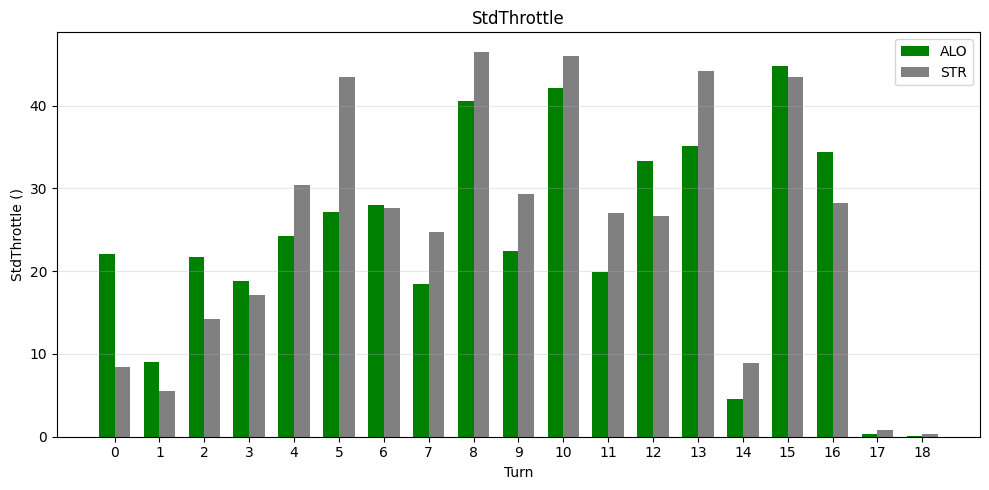

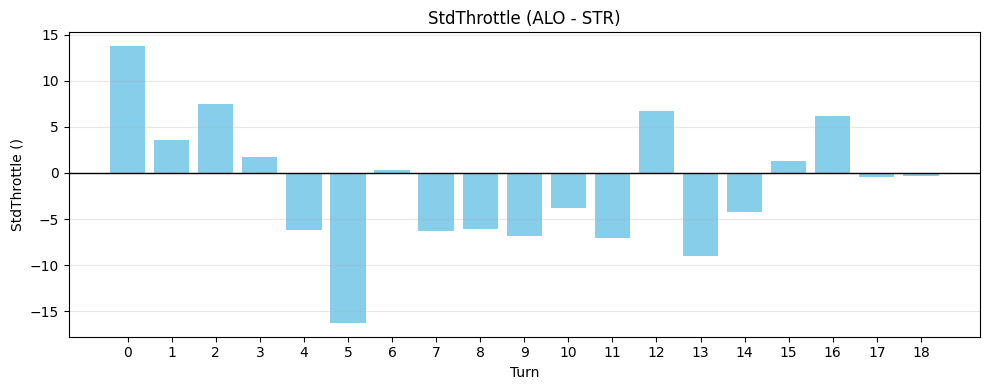

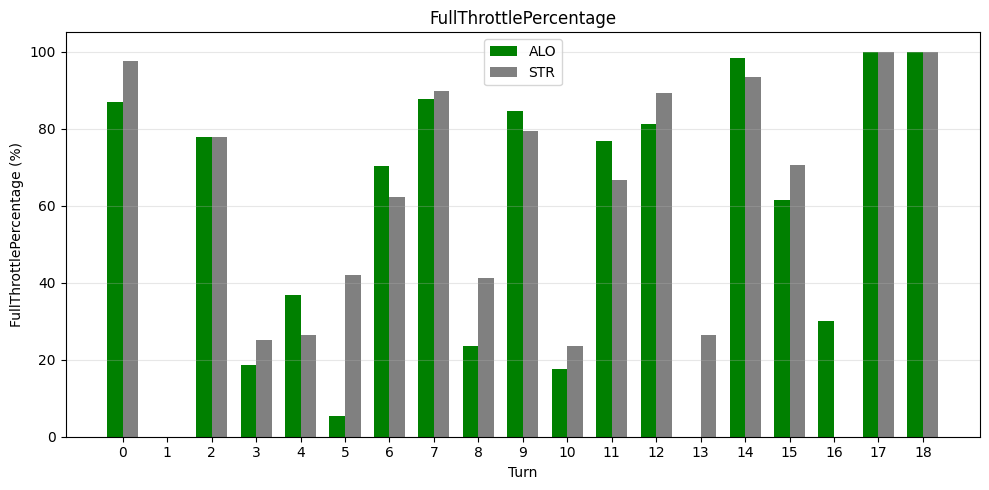

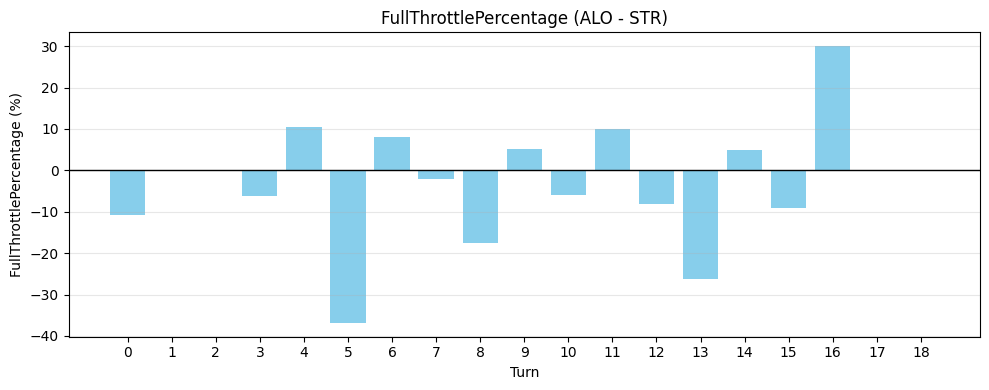

In [6]:
for feature, y_unit in [("MeanThrottle", ""), ("StdThrottle", ""), ("FullThrottlePercentage", "%")]:
    barplot_feature_comparison(lap_1["ThrottleSegments"], lap_2["ThrottleSegments"], driver_1, driver_2, turns, feature, y_unit=y_unit, include_zero=True)
    barplot_feature_delta(lap_1["ThrottleSegments"], lap_2["ThrottleSegments"], driver_1, driver_2, turns, feature, y_unit=y_unit, include_zero=True)

## Gear Shifts features

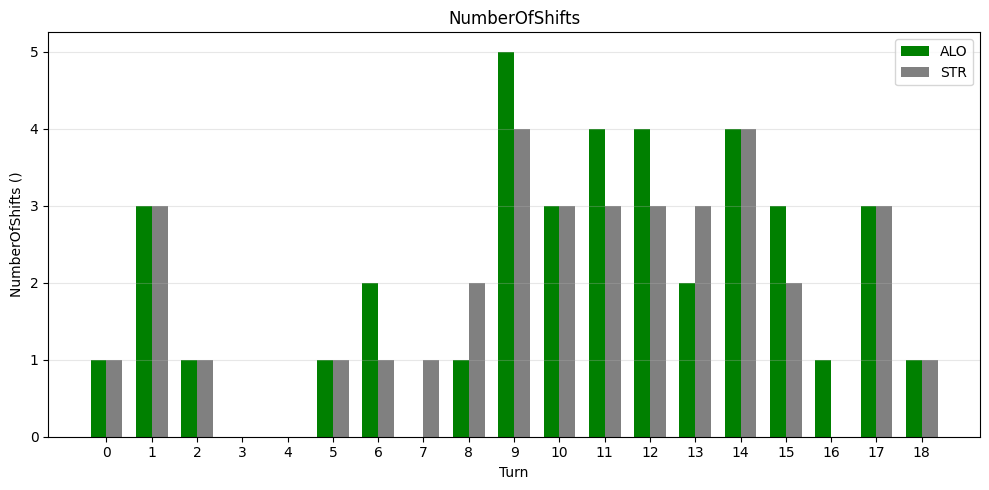

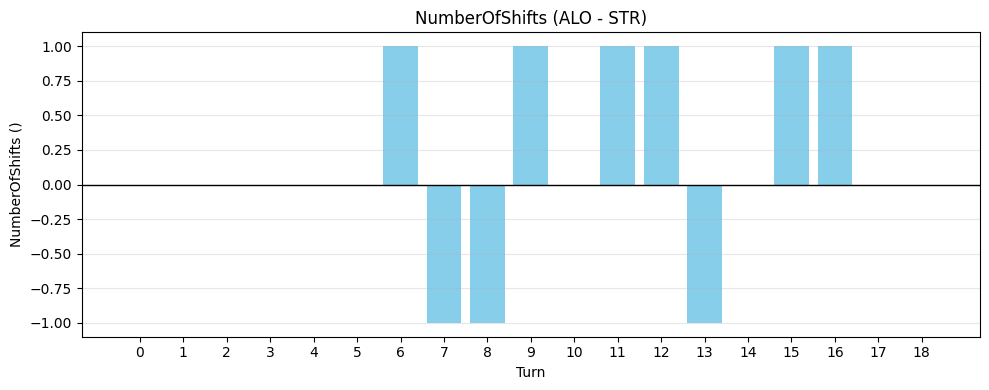

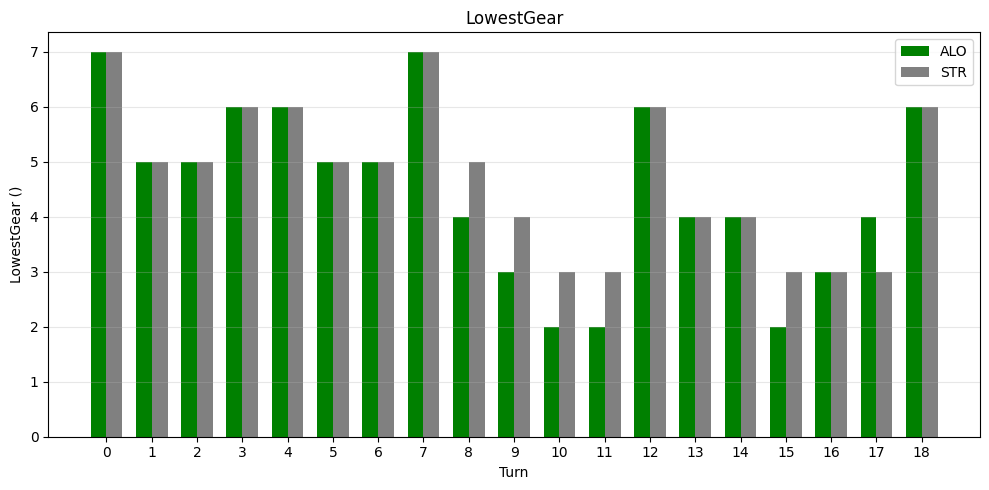

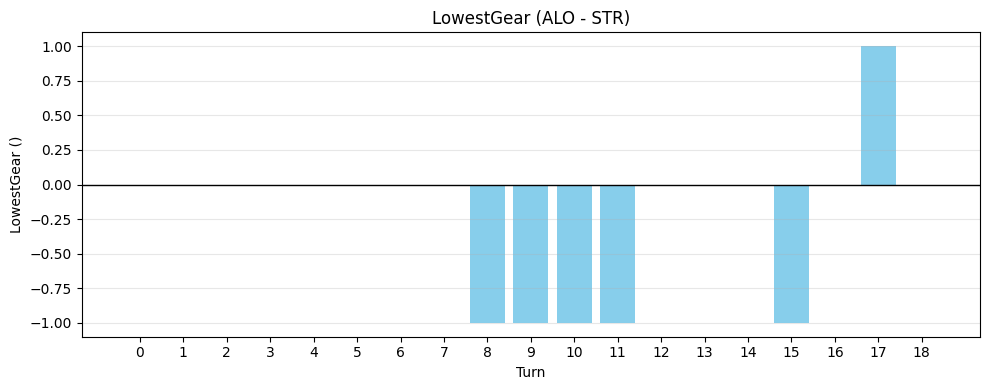

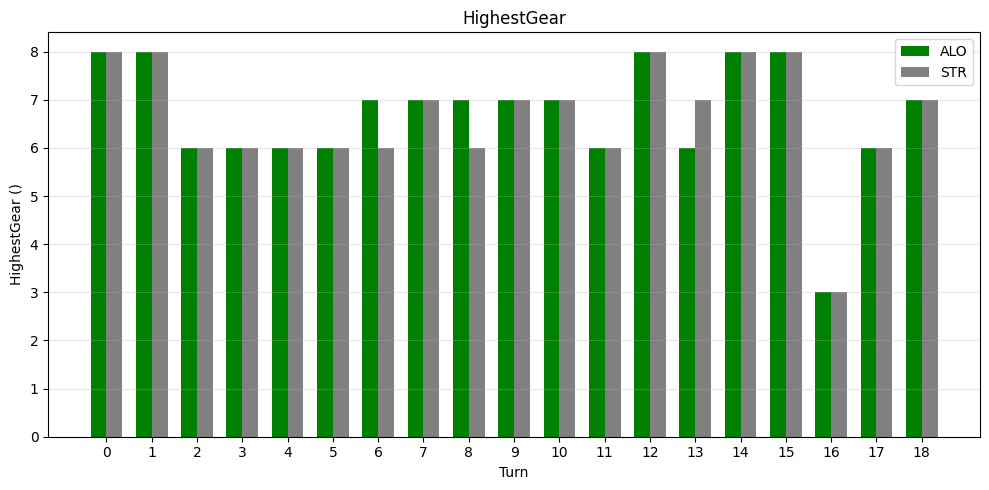

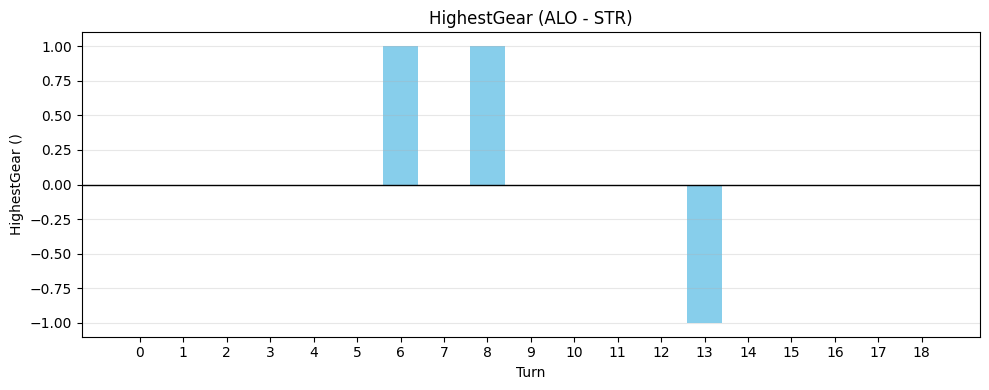

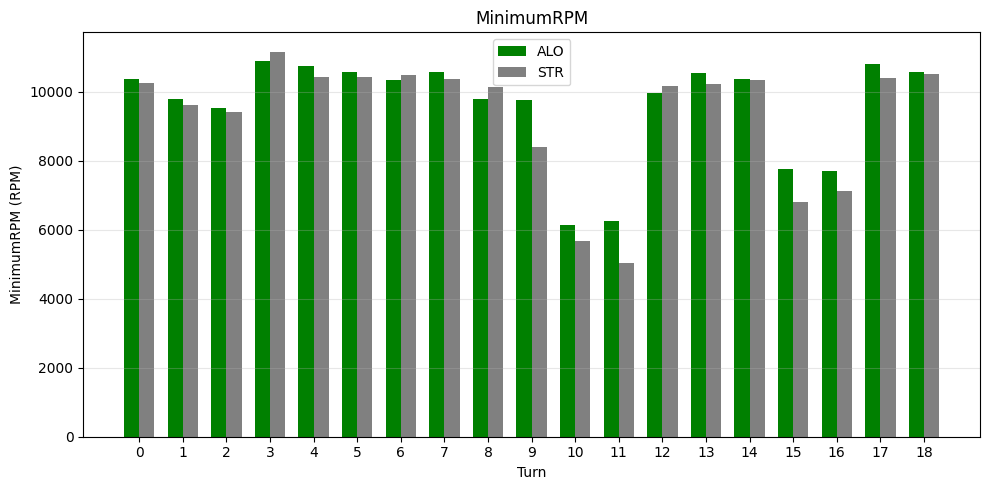

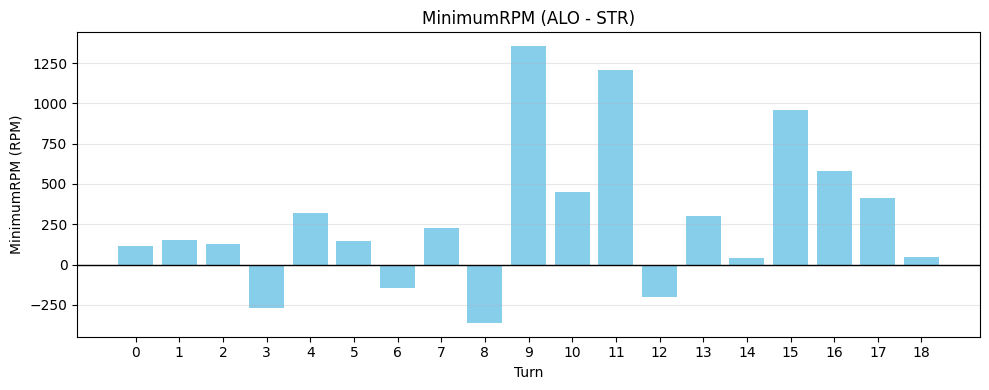

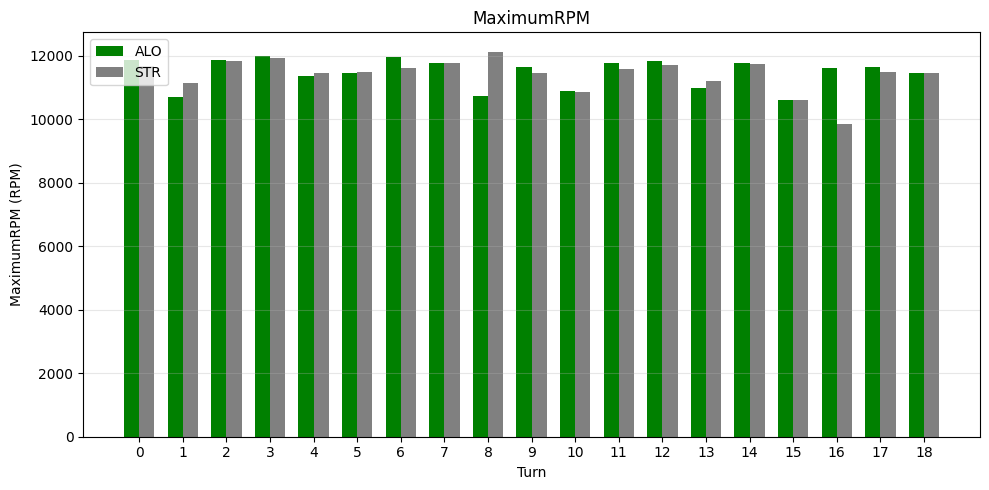

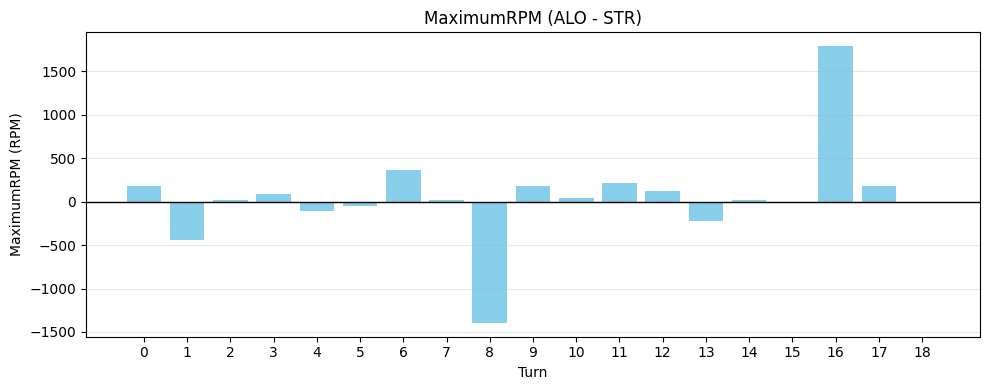

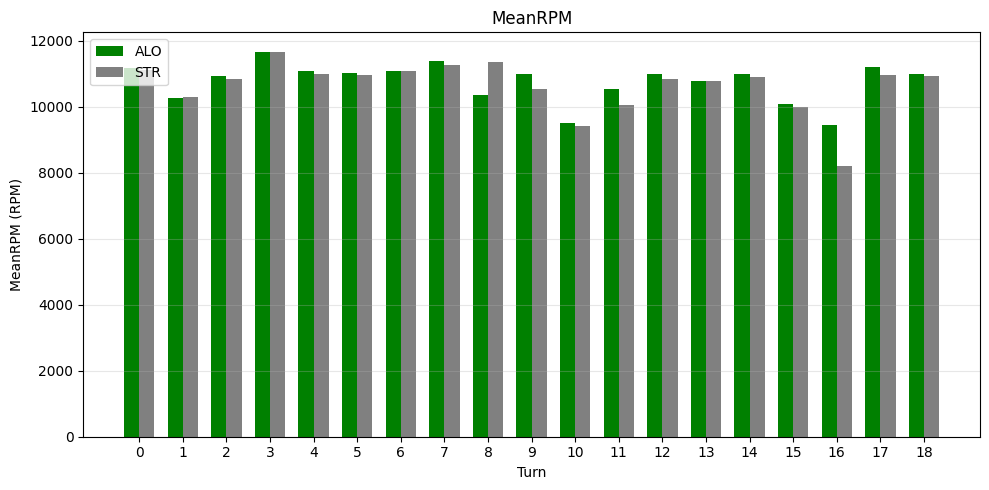

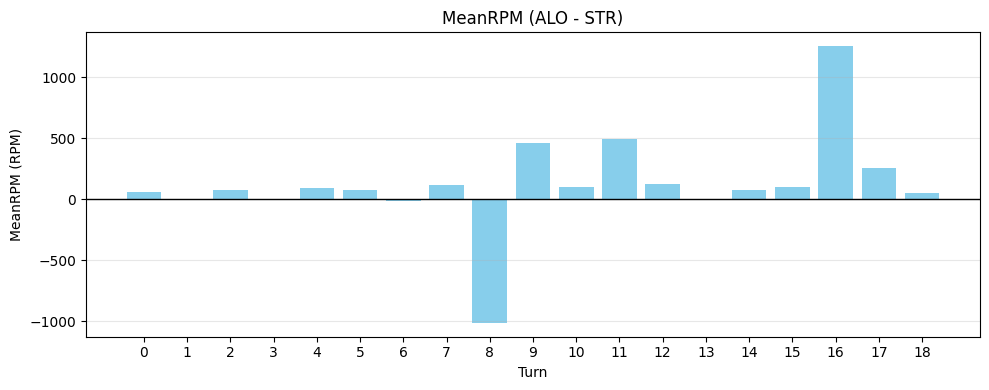

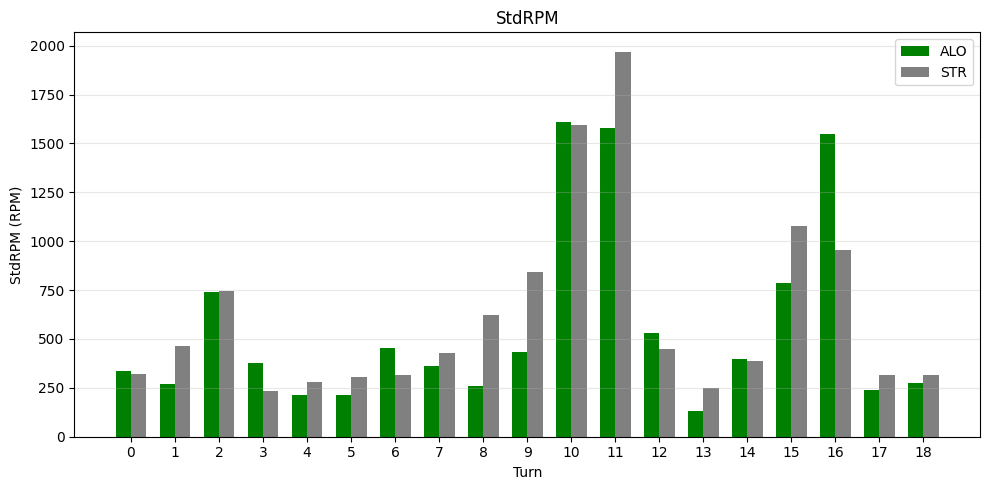

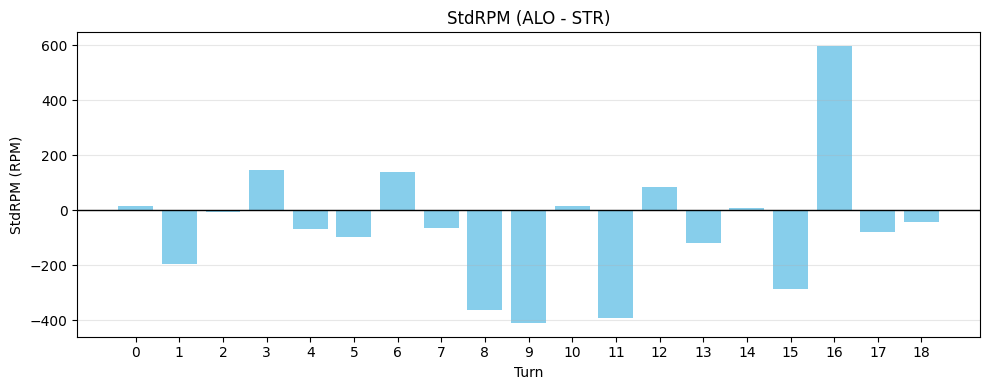

In [ ]:
for feature, y_unit in [("NumberOfShifts", ""), ("LowestGear", ""), ("HighestGear", ""), ("MeanRPM", "RPM"), ("StdRPM", "RPM")]:
    barplot_feature_comparison(lap_1["GearShifts"], lap_2["GearShifts"], driver_1, driver_2, turns, feature, y_unit=y_unit, include_zero=True)
    barplot_feature_delta(lap_1["GearShifts"], lap_2["GearShifts"], driver_1, driver_2, turns, feature, y_unit=y_unit, include_zero=True)